In [2]:
import sys
import importlib
sys.path.append('../../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

IN_seq_path = '../IN/data/in.reduce4.seq'
PR_seq_path = '../PR/data/pr.exper.reduce4.seq'    
RT_seq_path = '../RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq(IN_seq_path)
PR_all_seq = functions.read_seq(PR_seq_path)
RT_all_seq = functions.read_seq(RT_seq_path)

IN_consensus = '../IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = '../PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = '../RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

IN_redux = functions.get_redu_dict('../IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('../PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('../RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('../IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('../PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('../RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('../IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('../PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('../RT/data/rt.fullseq')

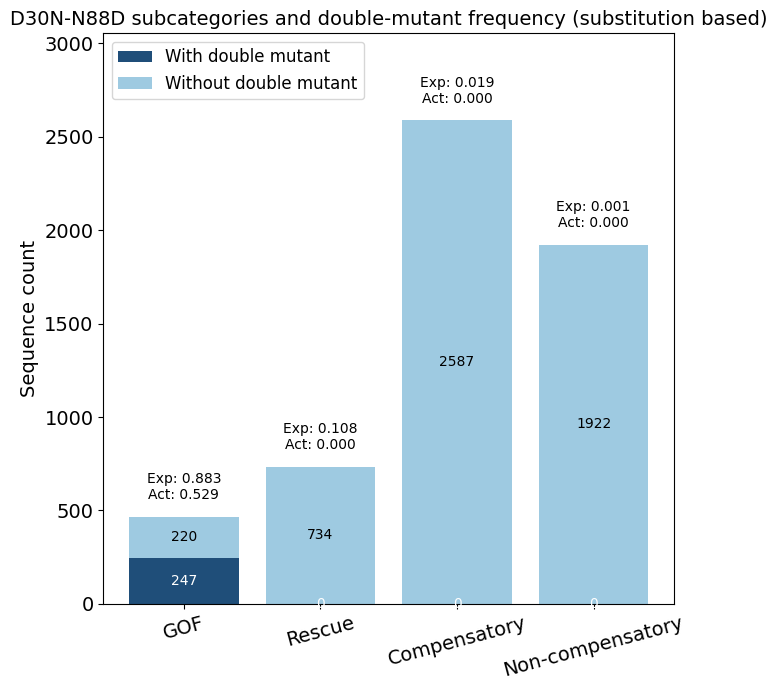

In [3]:
pair = ('D30N','N88D')

pair_reduced = (functions.unreduced_to_reduced(PR_redux, pair[0]), functions.unreduced_to_reduced(PR_redux, pair[1]))
pr_subcatagory_seqs = functions.seqs_to_subcatagories_v3(PR_all_seq,pair[0],pair[1],1,99,PR_J,PR_redux)

total_gof = len(pr_subcatagory_seqs['gof'])
gof_with_double_mutant = functions.calculate_double_mutant_frequency(pr_subcatagory_seqs['gof'],pair[0],pair[1],1,99,PR_redux)[0]
expected_prob_gof_with_double_mutant = functions.calculate_average_double_mutant_probablity_v3(pr_subcatagory_seqs['gof'],pair_reduced[0],pair_reduced[1],PR_J,1,99)
acutal_prob_gof_with_double_mutant = gof_with_double_mutant / total_gof if total_gof > 0 else 0

total_rescue = len(pr_subcatagory_seqs['rescue'])
rescue_with_double_mutant = functions.calculate_double_mutant_frequency(
    pr_subcatagory_seqs['rescue'], pair[0], pair[1], 1, 99, PR_redux
)[0]
expected_prob_rescue_with_double_mutant = functions.calculate_average_double_mutant_probablity_v3(
    pr_subcatagory_seqs['rescue'], pair_reduced[0], pair_reduced[1], PR_J, 1, 99
)
acutal_prob_rescue_with_double_mutant = (
    rescue_with_double_mutant / total_rescue if total_rescue > 0 else 0
)

total_compensatory = len(pr_subcatagory_seqs['compensatory'])
compensatory_with_double_mutant = functions.calculate_double_mutant_frequency(
    pr_subcatagory_seqs['compensatory'], pair[0], pair[1], 1, 99, PR_redux
)[0]
expected_prob_compensatory_with_double_mutant = functions.calculate_average_double_mutant_probablity_v3(
    pr_subcatagory_seqs['compensatory'], pair_reduced[0], pair_reduced[1], PR_J, 1, 99
)
acutal_prob_compensatory_with_double_mutant = (
    compensatory_with_double_mutant / total_compensatory if total_compensatory > 0 else 0
)

total_non_compensatory = len(pr_subcatagory_seqs['non-compensatory'])
non_compensatory_with_double_mutant = functions.calculate_double_mutant_frequency(
    pr_subcatagory_seqs['non-compensatory'], pair[0], pair[1], 1, 99, PR_redux
)[0]
expected_prob_non_compensatory_with_double_mutant = functions.calculate_average_double_mutant_probablity_v3(
    pr_subcatagory_seqs['non-compensatory'], pair_reduced[0], pair_reduced[1], PR_J, 1, 99
)
acutal_prob_non_compensatory_with_double_mutant = (
    non_compensatory_with_double_mutant / total_non_compensatory if total_non_compensatory > 0 else 0
)

import matplotlib.pyplot as plt

categories = ['GOF', 'Rescue', 'Compensatory', 'Non-compensatory']
totals = [total_gof, total_rescue, total_compensatory, total_non_compensatory]
double_mutants = [
    gof_with_double_mutant,
    rescue_with_double_mutant,
    compensatory_with_double_mutant,
    non_compensatory_with_double_mutant
]

categories = ['GOF', 'Rescue', 'Compensatory', 'Non-compensatory']
non_double = [t - d for t, d in zip(totals, double_mutants)]

x = range(len(categories))

plt.figure(figsize=(7, 7))
expected_probs = [
    expected_prob_gof_with_double_mutant,
    expected_prob_rescue_with_double_mutant,
    expected_prob_compensatory_with_double_mutant,
    expected_prob_non_compensatory_with_double_mutant,
]
actual_probs = [
    acutal_prob_gof_with_double_mutant,
    acutal_prob_rescue_with_double_mutant,
    acutal_prob_compensatory_with_double_mutant,
    acutal_prob_non_compensatory_with_double_mutant,
]

y_offset = max(totals) * 0.03
for xi, total, e_prob, a_prob in zip(x, totals, expected_probs, actual_probs):
    plt.text(
        xi,
        total + y_offset,
        f"Exp: {e_prob:.3f}\nAct: {a_prob:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.ylim(0, max(totals) * 1.18)
# Darker segment from y=0: double mutant count
bars1 = plt.bar(x, double_mutants, color='#1f4e79', label='With double mutant')

# Lighter segment stacked above: remaining sequences
bars2 = plt.bar(x, non_double, bottom=double_mutants, color='#9ecae1', label='Without double mutant')

plt.xticks(x, categories, rotation=15, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Sequence count', fontsize=14)
plt.title(f'{pair[0]}-{pair[1]} subcategories and double-mutant frequency (substitution based)', fontsize=14)

# Larger number labels on bars
plt.bar_label(bars1, fontsize=10, color='white', label_type='center')
plt.bar_label(bars2, fontsize=10, label_type='center')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


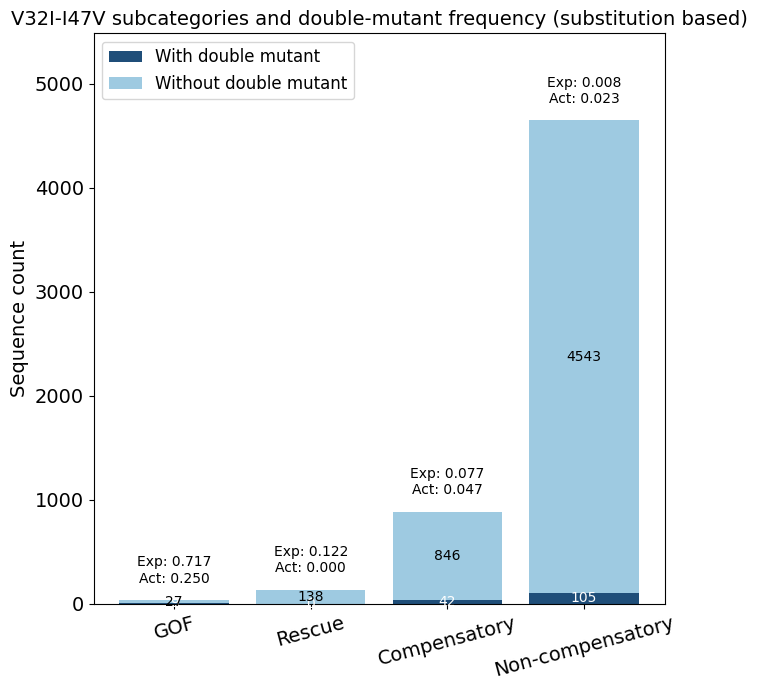

In [3]:
pair = ('V32I','I47V')
pair_reduced = (functions.unreduced_to_reduced(PR_redux, pair[0]), functions.unreduced_to_reduced(PR_redux, pair[1]))
pr_subcatagory_seqs = functions.seqs_to_subcatagories_v4(PR_all_seq,pair[0],pair[1],1,99,PR_J,PR_redux)

total_gof = len(pr_subcatagory_seqs['gof'])
gof_with_double_mutant = functions.calculate_double_mutant_frequency(pr_subcatagory_seqs['gof'],pair[0],pair[1],1,99,PR_redux)[0]
expected_prob_gof_with_double_mutant = functions.calculate_average_double_mutant_probablity_v4(pr_subcatagory_seqs['gof'],pair_reduced[0],pair_reduced[1],PR_J,1,99)
acutal_prob_gof_with_double_mutant = gof_with_double_mutant / total_gof if total_gof > 0 else 0

total_rescue = len(pr_subcatagory_seqs['rescue'])
rescue_with_double_mutant = functions.calculate_double_mutant_frequency(
    pr_subcatagory_seqs['rescue'], pair[0], pair[1], 1, 99, PR_redux
)[0]
expected_prob_rescue_with_double_mutant = functions.calculate_average_double_mutant_probablity_v4(
    pr_subcatagory_seqs['rescue'], pair_reduced[0], pair_reduced[1], PR_J, 1, 99
)
acutal_prob_rescue_with_double_mutant = (
    rescue_with_double_mutant / total_rescue if total_rescue > 0 else 0
)

total_compensatory = len(pr_subcatagory_seqs['compensatory'])
compensatory_with_double_mutant = functions.calculate_double_mutant_frequency(
    pr_subcatagory_seqs['compensatory'], pair[0], pair[1], 1, 99, PR_redux
)[0]
expected_prob_compensatory_with_double_mutant = functions.calculate_average_double_mutant_probablity_v4(
    pr_subcatagory_seqs['compensatory'], pair_reduced[0], pair_reduced[1], PR_J, 1, 99
)
acutal_prob_compensatory_with_double_mutant = (
    compensatory_with_double_mutant / total_compensatory if total_compensatory > 0 else 0
)

total_non_compensatory = len(pr_subcatagory_seqs['non-compensatory'])
non_compensatory_with_double_mutant = functions.calculate_double_mutant_frequency(
    pr_subcatagory_seqs['non-compensatory'], pair[0], pair[1], 1, 99, PR_redux
)[0]
expected_prob_non_compensatory_with_double_mutant = functions.calculate_average_double_mutant_probablity_v4(
    pr_subcatagory_seqs['non-compensatory'], pair_reduced[0], pair_reduced[1], PR_J, 1, 99
)
acutal_prob_non_compensatory_with_double_mutant = (
    non_compensatory_with_double_mutant / total_non_compensatory if total_non_compensatory > 0 else 0
)

import matplotlib.pyplot as plt

categories = ['GOF', 'Rescue', 'Compensatory', 'Non-compensatory']
totals = [total_gof, total_rescue, total_compensatory, total_non_compensatory]
double_mutants = [
    gof_with_double_mutant,
    rescue_with_double_mutant,
    compensatory_with_double_mutant,
    non_compensatory_with_double_mutant
]

categories = ['GOF', 'Rescue', 'Compensatory', 'Non-compensatory']
non_double = [t - d for t, d in zip(totals, double_mutants)]

x = range(len(categories))

plt.figure(figsize=(7, 7))
expected_probs = [
    expected_prob_gof_with_double_mutant,
    expected_prob_rescue_with_double_mutant,
    expected_prob_compensatory_with_double_mutant,
    expected_prob_non_compensatory_with_double_mutant,
]
actual_probs = [
    acutal_prob_gof_with_double_mutant,
    acutal_prob_rescue_with_double_mutant,
    acutal_prob_compensatory_with_double_mutant,
    acutal_prob_non_compensatory_with_double_mutant,
]

y_offset = max(totals) * 0.03
for xi, total, e_prob, a_prob in zip(x, totals, expected_probs, actual_probs):
    plt.text(
        xi,
        total + y_offset,
        f"Exp: {e_prob:.3f}\nAct: {a_prob:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.ylim(0, max(totals) * 1.18)
# Darker segment from y=0: double mutant count
bars1 = plt.bar(x, double_mutants, color='#1f4e79', label='With double mutant')

# Lighter segment stacked above: remaining sequences
bars2 = plt.bar(x, non_double, bottom=double_mutants, color='#9ecae1', label='Without double mutant')

plt.xticks(x, categories, rotation=15, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Sequence count', fontsize=14)
plt.title(f'{pair[0]}-{pair[1]} subcategories and double-mutant frequency (substitution based)', fontsize=14)

# Larger number labels on bars
plt.bar_label(bars1, fontsize=10, color='white', label_type='center')
plt.bar_label(bars2, fontsize=10, label_type='center')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import inspect

pair = ("D30N", "N88D")
pair_reduced = (
    functions.unreduced_to_reduced(PR_redux, pair[0]),
    functions.unreduced_to_reduced(PR_redux, pair[1]),
)

# GOF sequences from v2 and v3
pr_subcat_v2 = functions.seqs_to_subcatagories_v2(PR_all_seq, pair[0], pair[1], 1, 99, PR_J, PR_redux)
pr_subcat_v4 = functions.seqs_to_subcatagories_v4(PR_all_seq, pair[0], pair[1], 1, 99, PR_J, PR_redux)

gof_v2 = pr_subcat_v2["gof"]
gof_v4 = pr_subcat_v4["gof"]
compensatory_v4 = pr_subcat_v4["compensatory"]
non_compensatory_v4 = pr_subcat_v4["non-compensatory"]
results_data = []
for seq in gof_v4:
    if seq not in gof_v2:
        idx = next((i for i, s in enumerate(PR_all_seq) if s == seq), None)

        if idx is None:
            print("Sequence not found in reduced PR_all_seq.")
        else:
            full_seq = PR_all_seq_unreduced[idx]
            pos30_unreduced = full_seq[29]  # residue at position 30
            pos88_unreduced = full_seq[87]  # residue at position 88
        
            de1, de2, de12, dde = functions.calculate_dde_v4(pair_reduced[0], pair_reduced[1], seq, PR_J, 1, 99)
            prob = functions.calculate_double_mutant_probablity_v4(seq, pair_reduced[0], pair_reduced[1], PR_J, 1, 99)
            
            results_data.append({
                'index': idx,
                'Position_30_unreduced': pos30_unreduced,
                'Position_88_unreduced': pos88_unreduced,
                'de1': round(float(de1), 4),
                'de2': round(float(de2), 4),
                'de12': round(float(de12), 4),
                'dde': round(float(dde), 4),
                'Double_Mutant_Probability': round(prob, 4)
            })

df_results = pd.DataFrame(results_data)
df_results.to_csv('gof_v3_differences.csv', index=False)
print(f"Saved {len(df_results)} sequences to gof_v3_differences.csv")



results_data_v2 = []
for seq in gof_v2:
    idx = next((i for i, s in enumerate(PR_all_seq) if s == seq), None)

    if idx is None:
        print("Sequence not found in reduced PR_all_seq.")
    else:
        full_seq = PR_all_seq_unreduced[idx]
        pos30_unreduced = full_seq[29]  # residue at position 30
        pos88_unreduced = full_seq[87]  # residue at position 88
    
        de1, de2, de12, dde = functions.calculate_dde_v2(pair_reduced[0], pair_reduced[1], seq, PR_J, 1, 99)
        prob = functions.calculate_double_mutant_probablity_v2(seq, pair_reduced[0], pair_reduced[1], PR_J, 1, 99)
        
        results_data_v2.append({
            'index': idx,
            'Position_30_unreduced': pos30_unreduced,
            'Position_88_unreduced': pos88_unreduced,
            'de1': round(float(de1), 4),
            'de2': round(float(de2), 4),
            'de12': round(float(de12), 4),
            'dde': round(float(dde), 4),
            'Double_Mutant_Probability': round(prob, 4)
        })

df_results = pd.DataFrame(results_data_v2)
df_results.to_csv('gof_v2.csv', index=False)
print(f"Saved {len(df_results)} sequences to gof_v2.csv")

results_data_v4 = []
for seq in gof_v4:
    idx = next((i for i, s in enumerate(PR_all_seq) if s == seq), None)

    if idx is None:
        print("Sequence not found in reduced PR_all_seq.")
    else:
        full_seq = PR_all_seq_unreduced[idx]
        pos30_unreduced = full_seq[29]  # residue at position 30
        pos88_unreduced = full_seq[87]  # residue at position 88
    
        de1, de2, de12, dde = functions.calculate_dde_v4(pair_reduced[0], pair_reduced[1], seq, PR_J, 1, 99)
        prob = functions.calculate_double_mutant_probablity_v4(seq, pair_reduced[0], pair_reduced[1], PR_J, 1, 99)
        
        results_data_v4.append({
            'index': idx,
            'Position_30_unreduced': pos30_unreduced,
            'Position_88_unreduced': pos88_unreduced,
            'de1': round(float(de1), 4),
            'de2': round(float(de2), 4),
            'de12': round(float(de12), 4),
            'dde': round(float(dde), 4),
            'Double_Mutant_Probability': round(prob, 4)
        })

df_results = pd.DataFrame(results_data_v4)
df_results.to_csv('gof_v4.csv', index=False)
print(f"Saved {len(df_results)} sequences to gof_v4.csv")

for seq in compensatory_v4:
    idx = next((i for i, s in enumerate(PR_all_seq) if s == seq), None)

    if idx is None:
        print("Sequence not found in reduced PR_all_seq.")
    else:
        full_seq = PR_all_seq_unreduced[idx]
        pos30_unreduced = full_seq[29]  # residue at position 30
        pos88_unreduced = full_seq[87]  # residue at position 88
    
        de1, de2, de12, dde = functions.calculate_dde_v4(pair_reduced[0], pair_reduced[1], seq, PR_J, 1, 99)
        prob = functions.calculate_double_mutant_probablity_v4(seq, pair_reduced[0], pair_reduced[1], PR_J, 1, 99)
        
        results_data_v4.append({
            'index': idx,
            'Position_30_unreduced': pos30_unreduced,
            'Position_88_unreduced': pos88_unreduced,
            'de1': round(float(de1), 4),
            'de2': round(float(de2), 4),
            'de12': round(float(de12), 4),
            'dde': round(float(dde), 4),
            'Double_Mutant_Probability': round(prob, 4)
        })

df_results = pd.DataFrame(results_data_v4)
df_results.to_csv('compensatory_v4.csv', index=False)
print(f"Saved {len(df_results)} sequences to compensatory_v4.csv")

for seq in non_compensatory_v4:
    idx = next((i for i, s in enumerate(PR_all_seq) if s == seq), None)

    if idx is None:
        print("Sequence not found in reduced PR_all_seq.")
    else:
        full_seq = PR_all_seq_unreduced[idx]
        pos30_unreduced = full_seq[29]  # residue at position 30
        pos88_unreduced = full_seq[87]  # residue at position 88
    
        de1, de2, de12, dde = functions.calculate_dde_v4(pair_reduced[0], pair_reduced[1], seq, PR_J, 1, 99)
        prob = functions.calculate_double_mutant_probablity_v4(seq, pair_reduced[0], pair_reduced[1], PR_J, 1, 99)
        
        results_data_v4.append({
            'index': idx,
            'Position_30_unreduced': pos30_unreduced,
            'Position_88_unreduced': pos88_unreduced,
            'de1': round(float(de1), 4),
            'de2': round(float(de2), 4),
            'de12': round(float(de12), 4),
            'dde': round(float(dde), 4),
            'Double_Mutant_Probability': round(prob, 4)
        })

df_results = pd.DataFrame(results_data_v4)
df_results.to_csv('non_compensatory_v4.csv', index=False)
print(f"Saved {len(
    





    
)} sequences to non_compensatory_v4.csv")


Saved 0 sequences to gof_v3_differences.csv
Saved 117 sequences to gof_v2.csv
Saved 43 sequences to gof_v4.csv
Saved 2727 sequences to compensatory_v4.csv
Saved 4994 sequences to non_compensatory_v4.csv
